# Datasets Analysis

This notebook contains all steps required to prepare the data for the visualization, including data loading, cleaning, and transformation.

In [1]:
# imports
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import requests
import zipfile
import numpy as np
import contextily as cx

## First Analysis: GTFS Public Transport Dataset

The main dataset is the GTFS timetable dataset provided by Swiss Federal Railways via OpenTransportData. It contains the complete public transport schedule for Switzerland.

Dataset: https://data.opentransportdata.swiss/fr/dataset/timetable-2026-gtfs2020

Description of the dataset: https://opentransportdata.swiss/fr/cookbook/timetable-cookbook/gtfs/

## Structure : 

The dataset is composed of multiple CSV files describing different aspects of the network, including:
- `stops.txt` : geographic coordinates of stops and stations
- `routes.txt`: transport lines and operators
- `trips.txt`: individual vehicle trips
- `stop_times.txt`: schedule of arrivals and departures
- `transfers.txt`: transfer times between stops
- `calendar.txt`: service availability by date

In [2]:
# Configuration of paths
URL = "https://data.opentransportdata.swiss/fr/dataset/timetable-2026-gtfs2020/permalink"
GTFS_DIR = Path("data/gtfs")
ZIP_FILE = GTFS_DIR / "gtfs_fp2026.zip"

# Create the directory if it doesn't exist
GTFS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Download the ZIP file if it's not already present
if not ZIP_FILE.exists():
    print(f"Downloading GTFS data to {ZIP_FILE}...")
    # Stream the download to handle large files efficiently
    r = requests.get(URL, stream=True)
    r.raise_for_status() 
    with open(ZIP_FILE, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

In [4]:
# Extracting all files directly into data/gtfs/
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(GTFS_DIR)
    print(f"Files extracted to {GTFS_DIR}")

Files extracted to data/gtfs


In [5]:
# Loading the DataFrames
stops = pd.read_csv(GTFS_DIR / "stops.txt")
routes = pd.read_csv(GTFS_DIR / "routes.txt")
trips = pd.read_csv(GTFS_DIR / "trips.txt")
stop_times = pd.read_csv(GTFS_DIR / "stop_times.txt")
transfers = pd.read_csv(GTFS_DIR / "transfers.txt")
calendar = pd.read_csv(GTFS_DIR / "calendar.txt")

/var/folders/vh/qxbx1gcd7xb1gcxc5z2l5nmw0000gn/T/ipykernel_6800/2367158564.py:2: DtypeWarning: Columns (0: parent_station, 1: platform_code) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(GTFS_DIR / "stops.txt")


In [6]:
print("Stops:", stops.shape)
print("Routes:", routes.shape)
print("Trips:", trips.shape)
print("Stop times:", stop_times.shape)
print("Transfers:", transfers.shape)
print("Calendar:", calendar.shape)

Stops: (96978, 8)
Routes: (4853, 6)
Trips: (1192785, 9)
Stop times: (19169401, 7)
Transfers: (215787, 8)
Calendar: (42002, 10)


## Stops
The `stops` dataframe contains information about all the stops in the GTFS feed, including:
- `stop_id`: unique identifier for the stop
- `stop_name`: name of the stop
- `stop_lat` and `stop_lon`: geographic coordinates of the stop
- `location_type`: indicates if it's a stop (0) or a station (1)
- `parent_station`: if it's a stop that belongs to a station, this field contains the `stop_id` of the parent station
- `platform_code`: code for the platform (if applicable)
- `original_stop_id`: the original stop ID from the source data (if different from `stop_id`)

We keep only the relevant columns for our analysis: `stop_id`, `stop_name`, `stop_lat`, `stop_lon`, and `parent_station`.

In [7]:
# Keeping only the relevant columns for our analysis
stops = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'parent_station']]
stops.head()

,stop_id,stop_name,stop_lat,stop_lon,parent_station
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,Parent1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,Parent1100009
2,1100010,Atzenbach,47.714618,7.872350,Parent1100010
3,1100011,"Mambach, Brücke",47.728209,7.877470,Parent1100011
4,1100012,"Mambach, Mühlschau",47.734082,7.881387,Parent1100012


### Total Number of Stops in Switzerland
Stops correspond to stations, bus stops, tram stops, ...

In [8]:
total_stops = stops["stop_id"].nunique()
print("Total number of stops:", total_stops)

Total number of stops: 96978


## Routes

The `routes` dataframe contains information about the different routes in the GTFS feed, including:
 - `route_id`: unique identifier for each route
 - `agency_id`: identifier for the agency that operates the route
 - `route_short_name`: short name or number of the route (e.g., "S10", "IC", "IR46")
 - `route_long_name`: full name of the route (always empty in this dataset)
 - `route_desc`: description of the route (e.g., "S", "IC", "IR")
 - `route_type`: numeric code representing the route_desc

 We keep only the relevant columns for our analysis: `route_id`, `route_desc` (renamed `route_category`) and we map `route_type` (renamed `route_mode`) into the English name of the transportation mode as following:

In [9]:
# Keeping only the relevant columns for our analysis and mapping route_type to human-readable categories
routes = routes[['route_id', 'route_desc', 'route_type']]
route_type_map = {
    0: "Tram",
    1: "Metro",
    2: "Train",
    3: "Bus",
    4: "Ferry/Boat",
    5: "Cable car",
    6: "Cable car",
    7: "Funicular",

    700: "Bus",
    702: "Bus",
    705: "Bus",
    710: "Bus",
    715: "Bus",
    201: "Bus",
    202: "Bus",

    900: "Tram",
    401: "Metro",

    100: "Train",
    101: "Train",
    102: "Train",
    103: "Train",
    104: "Train",
    105: "Train",
    106: "Train",
    107: "Train",
    109: "Train",
    116: "Train",
    117: "Train",

    1000: "Ferry/Boat",

    1100: "Airplane",

    1300: "Cable car",
    1303: "Elevator",

    1400: "Funicular",

    1500: "Taxi",
    1700: "Unknown",
}

routes["route_mode"] = routes["route_type"].map(route_type_map).fillna("Other")
routes = routes[["route_id", "route_desc", "route_mode"]].rename(columns={"route_desc": "route_category"})
routes.head()

,route_id,route_category,route_mode
0,91-10-A-j26-1,S,Train
1,91-10-B-j26-1,S,Train
2,91-10-C-j26-1,S,Train
3,91-10-D-j26-1,EXT,Train
4,91-10-E-j26-1,T,Tram


### Distribution of Transport Modes

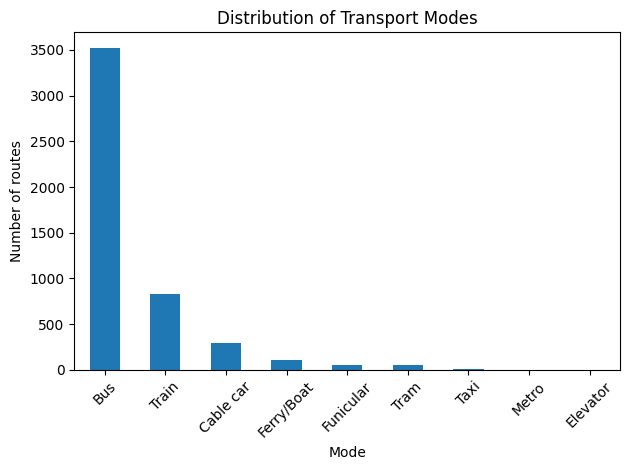

In [10]:
# Count routes by mode and plot the distribution
mode_counts = routes["route_mode"].value_counts().sort_values(ascending=False)

mode_counts.plot(kind="bar")
plt.title("Distribution of Transport Modes")
plt.xlabel("Mode")
plt.ylabel("Number of routes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Trips

The `trips` dataframe contains information about individual trips, including:
- `route_id`: identifier linking the trip to a route
- `service_id`: identifier linking the trip to a service schedule
- `trip_id`: unique identifier for each trip
- `trip_headsign`: text displayed to passengers (e.g., "Milano Centrale")
- `trip_short_name`: for trains, this field contains the train number
- `direction_id`: indicates the direction of the trip (0 or 1)
- `block_id`: used to identify which trips are operated by the same vehicle
- `original_trip_id`: Swiss Journey ID (SJYID)
- `hints`: specific traffic notes based on Swiss customer information standards

We keep only the relevant columns for our analysis: `route_id`, `service_id`, `trip_id`, `trip_headsign`, and `direction_id`.

In [11]:
# Keeping only the relevant columns for our analysis
trips = trips[["route_id", "service_id", "trip_id", "trip_headsign", "direction_id"]]
trips.head()

,route_id,service_id,trip_id,trip_headsign,direction_id
0,91-10-A-j26-1,TA+lbs00,1.TA.91-10-A-j26-1.1.H,Zürich HB,0
1,91-10-A-j26-1,TA+lbs00,10.TA.91-10-A-j26-1.1.H,Zürich HB,0
2,91-10-A-j26-1,TA+tal00,100.TA.91-10-A-j26-1.5.H,Zürich Selnau,0
3,91-10-A-j26-1,TA+ral00,101.TA.91-10-A-j26-1.5.H,Zürich Selnau,0
4,91-10-A-j26-1,TA+tal00,102.TA.91-10-A-j26-1.5.H,Zürich Selnau,0


### Distribution of Trips per Route

We count how many unique trip_ids are associated with each route_id.

This counts EVERY planned trip over the entire duration of the GTFS feed (which span an entire year).

This is a measure of "Network Volume" rather than "Daily Frequency."

To get the frequency for a specific day, we would need to filter by a specific 'service_id' first.

In [12]:
trips_per_route = trips.groupby("route_id")["trip_id"].count()
print("Statistical summary of trips per route (for a year):")
print(trips_per_route.describe())

Statistical summary of trips per route (for a year):
count     4853.000000
mean       245.783021
std        909.750204
min          1.000000
25%         13.000000
50%         49.000000
75%        153.000000
max      26722.000000
Name: trip_id, dtype: float64


## Stop times

The stop_times dataframe contains information about the scheduled times for each trip at each stop, including:
- `trip_id`: unique identifier for each trip
- `arrival_time`: scheduled arrival time at the stop (in HH:MM:SS format, can be >24:00:00 for trips that go past midnight)
- `departure_time`: scheduled departure time from the stop (in HH:MM:SS format, can be >24:00:00 for trips that go past midnight)
- `stop_id`: unique identifier for each stop
- `stop_sequence`: the order of stops for a given trip (starting at 1 for the first stop)
- `pickup_type` and `drop_off_type`: indicate whether passengers can board or alight at the stop (0 = regular, 1 = no pickup/drop-off, 2 = phone agency, 3 = coordinate with driver)

We keep only the relevant columns for our analysis and convert the arrival and departure times to datetime objects for easier analysis.

In [13]:
# Keeping only the relevant columns for our analysis
stop_times = stop_times[["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"]]
stop_times.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence
0,1.TA.91-10-A-j26-1.1.H,12:37:00,12:37:00,8503054:0:1,1
1,1.TA.91-10-A-j26-1.1.H,12:38:00,12:38:00,8503053:0:1,2
2,1.TA.91-10-A-j26-1.1.H,12:39:00,12:39:00,8503052:0:1,3
3,1.TA.91-10-A-j26-1.1.H,12:42:00,12:42:00,8503051:0:1,4
4,1.TA.91-10-A-j26-1.1.H,12:45:00,12:45:00,8503090:0:1,5


### Arrival and departure time analysis

In [14]:
# We show the range of arrival times to understand the span of service hours
print("Range of arrival times:")
print("Earliest arrival time:", stop_times["arrival_time"].min())
print("Latest arrival time:", stop_times["arrival_time"].max())

# We show the range of departure times to understand the span of service hours
print("\nRange of departure times:")
print("Earliest departure time:", stop_times["departure_time"].min())
print("Latest departure time:", stop_times["departure_time"].max())

Range of arrival times:
Earliest arrival time: 00:00:00
Latest arrival time: 46:24:00

Range of departure times:
Earliest departure time: 00:00:00
Latest departure time: 46:24:00


We see that the earliest arrival time is around 00:00:00 and the latest arrival time is 46:24:00, which indicates that some trips are scheduled to arrive well past midnight, likely due to overnight services or trips that start late at night and end after midnight.

### Number of departures per station

In [15]:
# Count the number of departures per station and show the statistical summary to understand the distribution of service frequency across stations
departures_per_station = stop_times.groupby("stop_id")["trip_id"].count()
departures_per_station.describe()

count    61833.000000
mean       310.018938
std        890.562048
min          1.000000
25%         22.000000
50%         62.000000
75%        216.000000
max      34756.000000
Name: trip_id, dtype: float64

In [16]:
# Show the top 10 stops with the most departures to identify key hubs in the network
top_departures = departures_per_station.sort_values(ascending=False).head(10)

top_departures = top_departures.reset_index()
top_departures = top_departures.merge(stops[["stop_id","stop_name"]], on="stop_id")

top_departures

,stop_id,trip_id,stop_name
0,8505095:0:D,34756,"Schwyz, Zentrum"
1,8590052:0:10000,21333,"Ostermundigen, Rüti"
2,8595932:0:10000,20822,"Schliern, Bus-Endstation"
3,8505098:0:A,19316,"Brunnen, Bahnhof"
4,8577430:0:10000,18121,"Ibach, Mythen Center"
5,8577432:0:10000,18116,"Schwyz, Steisteg"
6,8507110:0:B,16362,"Bern, Zytglogge"
7,8577431:0:10000,16021,"Schwyz, Lücken"
8,8577430:0:10001,16016,"Ibach, Mythen Center"
9,8579896:0:C,15026,"Bern, Hirschengraben"


## Transfers

The transfers dataframe contains information about possible transfers between stops, including:

- `from_stop_id`: the starting stop identifiers for the transfer.
- `end_stop_id`: the destination stop identifiers for the transfer.
- `from_route_id` / `to_route_id`: specific routes involved in the transfer, if applicable.
- `from_trip_id` / `to_trip_id`: specific trips involved in the transfer, if applicable.
- `transfer_type`: defines the connection logic:
    - `1` (Timed/Guaranteed Transfer): This indicates a connection where the departing vehicle is expected to wait for arriving passengers. No `min_transfer_time` is provided.
    - `2` (Minimum Time Transfer): A standard connection where the passenger must walk between stops. The duration is specified in `min_transfer_time`.
    - `4` (In-Seat Transfer): Passengers do not need to change vehicles. This is common for "multi-destination trains" that split (e.g., at Spiez) where the `trip_id` changes but the traveler stays on board.
- `min_transfer_time`: The minimum time required in seconds for `type 2` transfers.

### Transfer type analysis

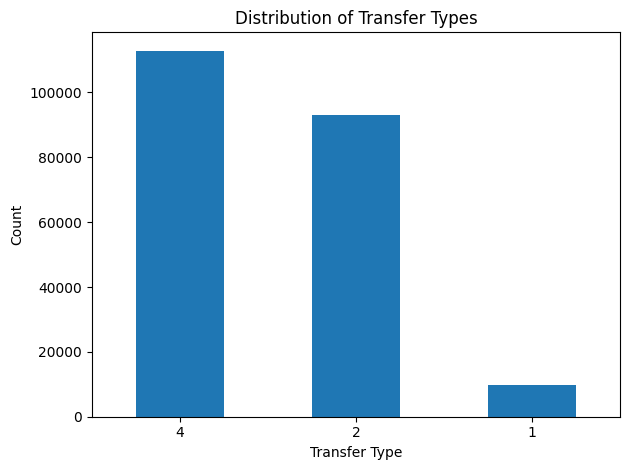

In [17]:
# We plot the distribution of transfer types to understand the prevalence of different transfer conditions
transfers["transfer_type"].value_counts().plot(kind="bar")
plt.title("Distribution of Transfer Types")
plt.xlabel("Transfer Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Transfer time analysis

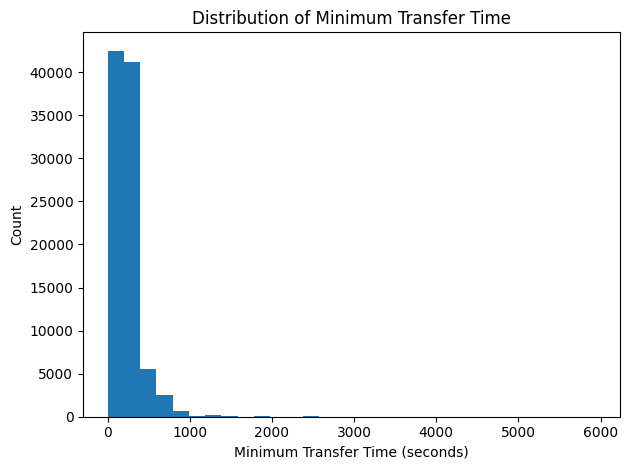

In [18]:
# We plot the distribution of transfer time to understand how long passengers typically have to wait for a transfer
transfers["min_transfer_time"].plot(kind="hist", bins=30)
plt.title("Distribution of Minimum Transfer Time")
plt.xlabel("Minimum Transfer Time (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Calendar

The calendar dataframe contains information about the service availability for each service_id, which can be used to determine on which days certain routes operate. It includes:
- `service_id`: Unique identifier for each service schedule.
- `monday` to `sunday`: Binary indicators (1 or 0) for whether the service operates on each day of the week.
- `start_date` and `end_date`: The date range during which the service is active.


### Range of service

In [19]:
# Showing the range of service dates to understand the coverage of the timetable
print(f"Calendar covers from {calendar['start_date'].min()} to {calendar['end_date'].max()}")

Calendar covers from 20251214 to 20261212


### Service days analysis

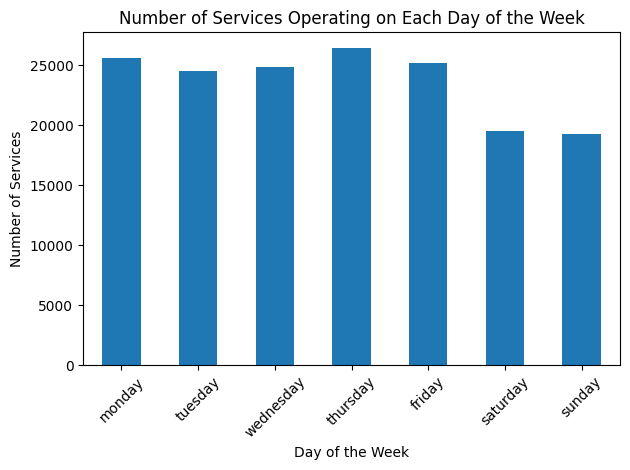

In [20]:
# Plot the distribution of service days to see how many services operate on each day of the week
service_days = calendar[["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]].sum()
service_days.plot(kind="bar")
plt.title("Number of Services Operating on Each Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Services")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Stops where InterCity trains stop

In [21]:
# We look for routes that are InterCity (IC) trains based on their route_category 'IC'
ic_routes = routes[routes['route_category'] == 'IC']
ic_trips = trips[trips['route_id'].isin(ic_routes['route_id'])]

# Get the stop_id where IC trains actually stop
ic_stop_ids = stop_times[stop_times['trip_id'].isin(ic_trips['trip_id'])]['stop_id'].unique()
ic_stops = stops[stops['stop_id'].isin(ic_stop_ids)]

print(f"Number of IC stops identified: {len(ic_stops)}")

Number of IC stops identified: 408


### Connectivity of InterCity (IC) Hubs

In [22]:
# Filter stop_times to include only arrivals/departures at identified IC stops
ic_stop_times = stop_times[stop_times['stop_id'].isin(ic_stop_ids)]

# Calculate the connectivity score by counting the number of IC trains serving each stop
# This represents the total service volume for IC trains over the feed period
connectivity = ic_stop_times.groupby('stop_id').size().reset_index(name='num_trains')

# Merge connectivity scores back with the IC stops dataframe to get station names
ic_hubs_analysis = ic_stops.merge(connectivity, on='stop_id')

# Display the top 5 most connected hubs
print("Top 5 hubs by number of scheduled IC trains over the feed period:")
print(ic_hubs_analysis.sort_values(by='num_trains', ascending=False)[['stop_name', 'num_trains']].head(5))

Top 5 hubs by number of scheduled IC trains over the feed period:
           stop_name  num_trains
369   Lyon Part Dieu        3808
169  Zürich Oerlikon        2816
89            Morges        2728
252       Winterthur        2659
93         Renens VD        2618


## Second Analysis: Population Density Dataset

The data used for this analysis can be found in the following file: `population.xlsx`

Columns are grouped in blocks:

| Block | Meaning |
| ----- | ------- |
| Total / Homme / Femme | Total population | 
| Total.1 / Homme.1 / Femme.1 | Swiss population |
| Total.2 / Homme.2 / Femme.2 | Foreign population |
| Total.3 / Homme.3 / Femme.3 | Non-permanent population |

In [23]:
df = pd.read_excel("data/population.xlsx",sheet_name=0, header=3)

df = df.rename(columns={
    "Unnamed: 0": "region",
    "Total": "total_pop",
    "Homme": "male",
    "Femme": "female",
    "Total.1": "swiss_pop",
    "Total.2": "foreign_pop",
    "Total.3": "non_permanent_pop"
})

df = df.dropna(subset=["region"])
df.head()

,region,total_pop,male,female,swiss_pop,Homme.1,Femme.1,foreign_pop,Homme.2,Femme.2,non_permanent_pop,Homme.3,Femme.3
0,Suisse,9067144.0,4509263.0,4557881.0,6573203.0,3198037.0,3375166.0,2493941.0,1311226.0,1182715.0,84151.0,49840.0,34311.0
1,Région lémanique,1762775.0,866090.0,896685.0,1150317.0,549260.0,601057.0,612458.0,316830.0,295628.0,24380.0,13649.0,10731.0
2,Vaud,857445.0,422116.0,435329.0,565375.0,269528.0,295847.0,292070.0,152588.0,139482.0,9925.0,5357.0,4568.0
3,Valais,372573.0,186207.0,186366.0,274902.0,133754.0,141148.0,97671.0,52453.0,45218.0,10030.0,6103.0,3927.0
4,Genève,532757.0,257767.0,274990.0,310040.0,145978.0,164062.0,222717.0,111789.0,110928.0,4425.0,2189.0,2236.0


### Basic Statistics

Here, we want to see all relevant information that can be found using this data.

#### Total Population

In [24]:
total_population = df.loc[df["region"] == "Suisse", "total_pop"].values[0]
print("Total population Switzerland:", total_population)

Total population Switzerland: 9067144.0


#### Population by Canton

In [25]:
cantons = df[~df["region"].str.contains("Région|Suisse")]

cantons[["region", "total_pop"]].sort_values("total_pop", ascending=False).head(10)

,region,total_pop
5,Espace Mittelland,1964984.0
15,Zurich,1622494.0
6,Berne,1072948.0
2,Vaud,857445.0
14,Argovie,737276.0
21,Saint-Gall,541026.0
4,Genève,532757.0
25,Lucerne,438692.0
3,Valais,372573.0
31,Tessin,358696.0


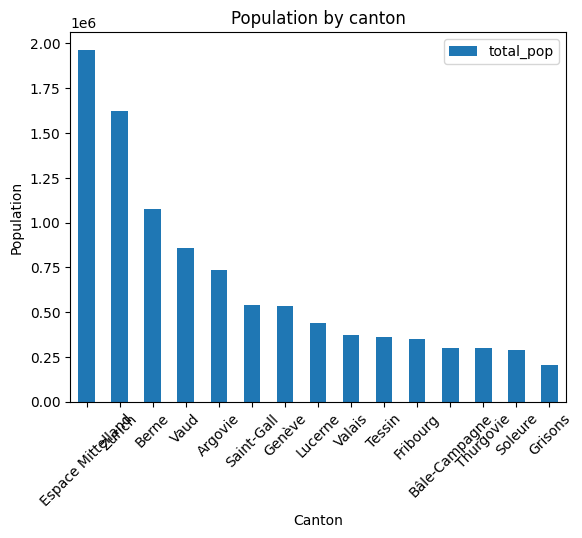

In [26]:
cantons_sorted = cantons.sort_values("total_pop", ascending=False)

cantons_sorted.head(15).plot(
    x="region",
    y="total_pop",
    kind="bar"
)

plt.title("Population by canton")
plt.ylabel("Population")
plt.xlabel("Canton")
plt.xticks(rotation=45)
plt.show()

## Third Analysis: Real Estate Index Dataset

We will need to use two datasets for this analysis:

- `price-realestate.xlslx`, which maps the price of real estate according to the type of municipality
- `types-communes.csv`, which maps all swiss municipalities to a type (1 through 5)

The two datasets are not directly joinable via IDs, but they share a common conceptual classification:
- `price-realestate.xlslx` -> GemeindeTyp 1–5
- `types-communes.csv` -> Municipality categories

We will map them manually:
| GemeindeTyp | Category |
| ----------- | -------- |
| 1 | Urban municipality within a major metropolitan area |
| 2 | Urban municipality in a medium-sized metropolitan area |
| 3 | Urban municipality in a small town or outside an urban area |
| 4 | Intermediate municipality |
| 5 | Rural municipality |

In [27]:
xls = pd.read_excel("data/price-realestate.xlsx")
csv = pd.read_csv("data/types-communes.csv")

df = xls.rename(columns={"Sprache / Langue / Lingua / Language": "type"})
df = df[df["type"].astype(str).str.contains("GemeindeTyp", na=False)]

df = df[["type", "Unnamed: 1"]].rename(columns={"Unnamed: 1": "value"})
df["type_id"] = df["type"].str.extract(r'(\d)').astype(int)

df = df.dropna(subset=["value"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")

agg = df.groupby("type_id")["value"].mean().reset_index()

mapping = {
    1: "Urban municipality within a major metropolitan area",
    2: "Urban municipality in a medium-sized metropolitan area",
    3: "Urban municipality in a small town or outside an urban area",
    4: "Intermediate municipality",
    5: "Rural municipality"
}

agg["category"] = agg["type_id"].map(mapping)

agg

,type_id,value,category
0,1,20.539333,Urban municipality within a major metropolitan...
1,2,12.999333,Urban municipality in a medium-sized metropoli...
2,3,6.984000,Urban municipality in a small town or outside ...
3,4,16.930667,Intermediate municipality
4,5,9.213333,Rural municipality


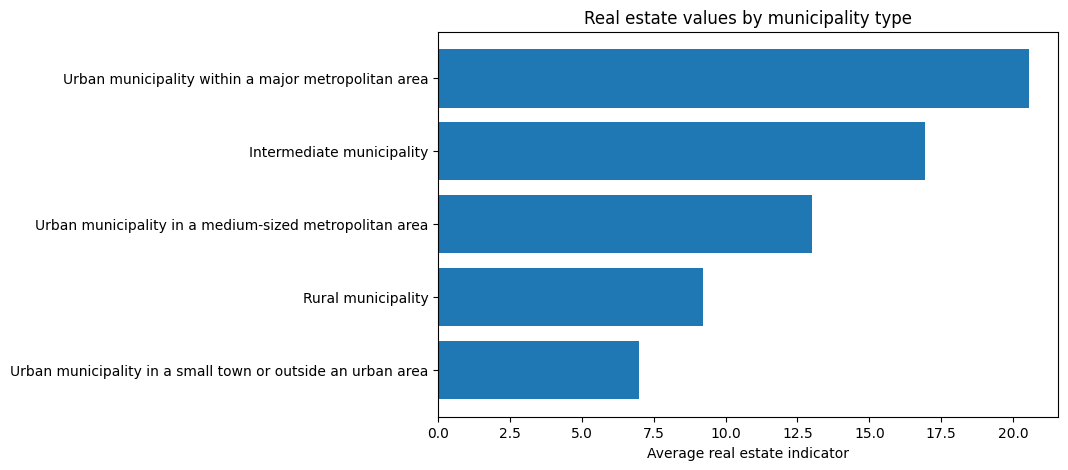

In [28]:
agg_sorted = agg.sort_values("value", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(agg_sorted["category"], agg_sorted["value"])
plt.xlabel("Average real estate indicator")
plt.title("Real estate values by municipality type")
plt.gca().invert_yaxis()
plt.show()

In [29]:
boundaries = gpd.read_file("data/Boundaries_K4_Commune_20260101.gpkg")

fr_to_en = {
    "Commune urbaine d'une grande agglomération": "Urban municipality within a major metropolitan area",
    "Commune urbaine d'une agglomération moyenne": "Urban municipality in a medium-sized metropolitan area",
    "Commune urbaine d'une petite ou hors agglomération": "Urban municipality in a small town or outside an urban area",
    "Commune intermédiaire": "Intermediate municipality",
    "Commune rurale": "Rural municipality"
}

csv["category"] = csv["TYP"].map(fr_to_en)

muni_map = boundaries.merge(
    csv,
    left_on="GDENR",
    right_on="GEO_ID",
    how="left"
)

muni_map = muni_map.merge(
    agg[["category", "value"]],
    on="category",
    how="left"
)

#### Municipality type map
This map shows the distribution and location of the municipalities of Switzerland

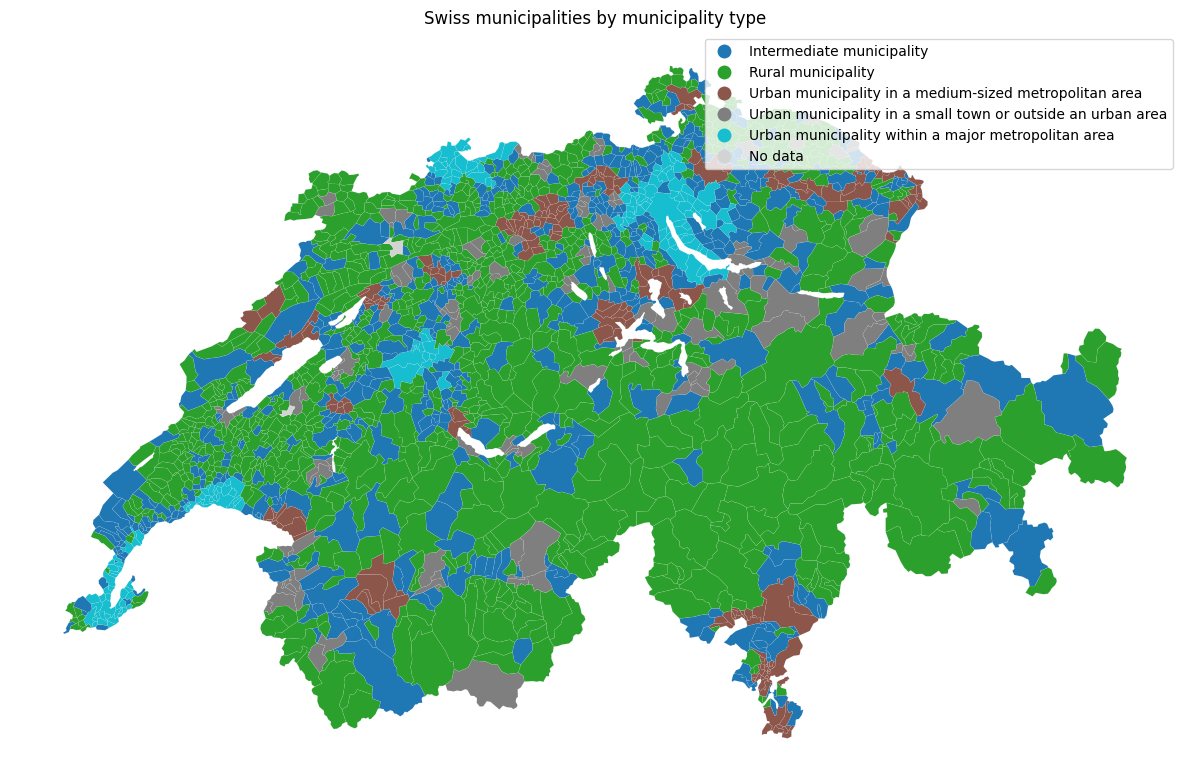

In [30]:
fig, ax = plt.subplots(figsize=(12, 10))
muni_map.plot(
    column="category",
    ax=ax,
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Swiss municipalities by municipality type")
ax.axis("off")
plt.tight_layout()
plt.show()

#### Real estate indicator map
This map shows the real estate indicator per municipality in Switzerland

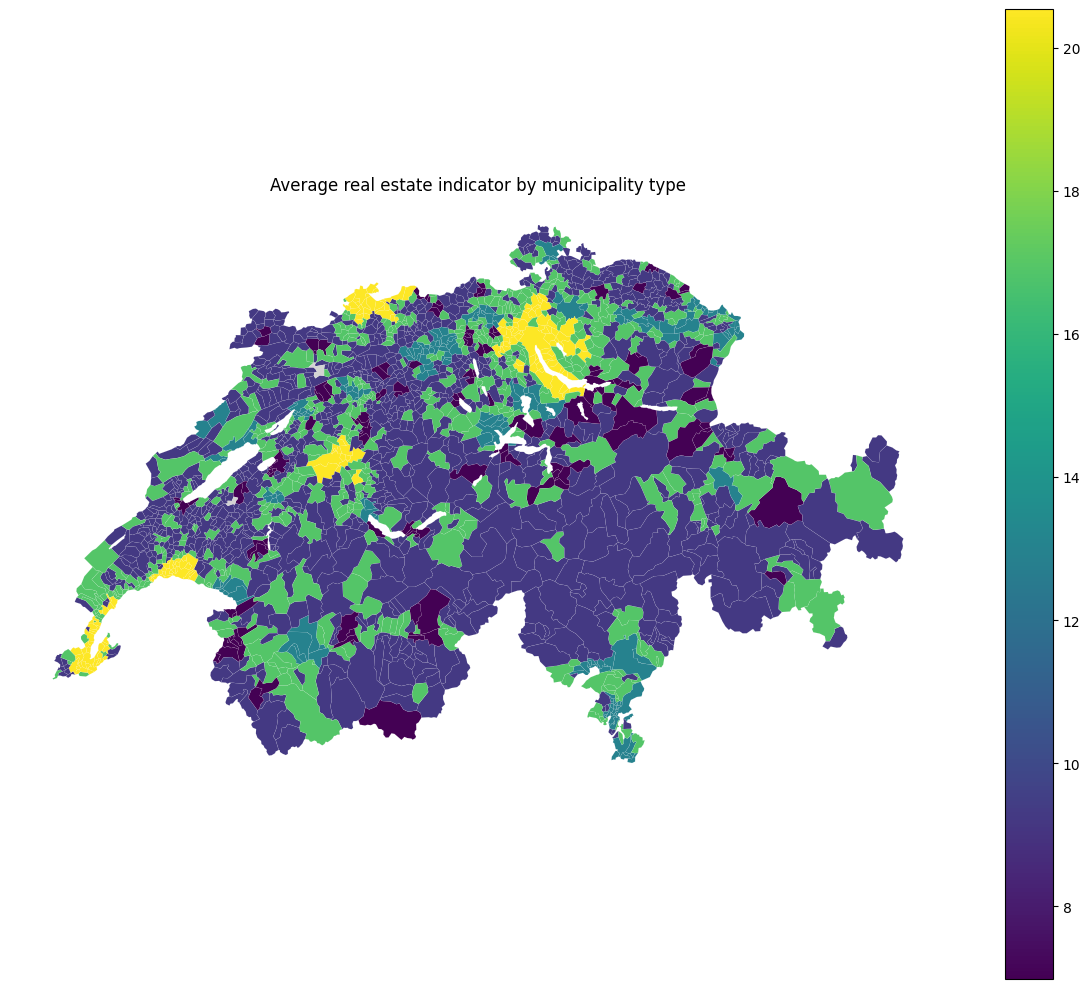

In [31]:
fig, ax = plt.subplots(figsize=(12, 10))
muni_map.plot(
    column="value",
    cmap="viridis",
    ax=ax,
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Average real estate indicator by municipality type")
ax.axis("off")
plt.tight_layout()
plt.show()

## Fourth Analysis: Employment Distribution Dataset

We will be using several datasets for this analysis:
- `STATENT_2023.csv`, 
- `STATENT_NOLOC_2023.csv`,
- `STATENT_GMDE_2023.csv`,
- and `Boundaries_K4_Commune_20260101.gpkg`.

This will help us describe the job employement within Switzerland

In [32]:
path_statent = Path("data/STATENT_2023.csv")
df_statent = pd.read_csv(path_statent, sep=";")

path_noloc = Path("data/STATENT_NOLOC_2023.csv")
df_noloc = pd.read_csv(path_noloc, sep=";")

path_gmde = Path("data/STATENT_GMDE_2023.csv")
df_gmde = pd.read_csv(path_gmde, sep=";")

In [33]:
#Keep only commune ID, and total jobs (B08EMPT = total employment).
df_gmde = df_gmde[["GDENR", "GDE_HISTID", "B08EMPT"]].copy()
df_gmde = df_gmde.rename(columns={
    "GDENR": "commune_id",
    "GDE_HISTID": "commune_hist_id",
    "B08EMPT": "total_jobs"
})

In [34]:
cantons = gpd.read_file("data/Boundaries_K4_Commune_20260101.gpkg")
print(cantons.columns, cantons.crs)
cantons.head()

Index(['GDENAME', 'GDEHISTID', 'GDENR', 'KTNAME', 'KTNR', 'KTKZ', 'geometry'], dtype='str') EPSG:2056


,GDENAME,GDEHISTID,GDENR,KTNAME,KTNR,KTKZ,geometry
0,Vionnaz,10078,6158,Valais / Wallis,23,VS,"POLYGON Z ((2559340 1129908 NaN, 2559838 11280..."
1,Speicher,10157,3023,Appenzell Ausserrhoden,15,AR,"POLYGON Z ((2750577 1255660 NaN, 2751887 12553..."
2,Zwischbergen,10159,6011,Valais / Wallis,23,VS,"POLYGON Z ((2649858 1121568 NaN, 2651538 11225..."
3,Villars-sur-Glâne,10162,2228,Fribourg / Freiburg,10,FR,"POLYGON Z ((2577605 1182163.001 NaN, 2577543 1..."
4,Villarsel-sur-Marly,10165,2230,Fribourg / Freiburg,10,FR,"POLYGON Z ((2578863 1179495.001 NaN, 2579945 1..."


In [35]:
df_cantons =  cantons[["GDENR", "GDEHISTID", "KTNR", "KTNAME"]].copy()
df_cantons = df_cantons.rename(columns={
    "GDENR": "commune_id",
    "GDEHISTID": "commune_hist_id",
    "KTNR": "canton_id",
    "KTNAME": "canton_name"
}).drop_duplicates()

In [36]:
df_merge = df_gmde.merge(
    df_cantons,
    on=["commune_id", "commune_hist_id"],
    how="left"
)
missing = df_merge[df_merge["canton_id"].isna()]
print("Unmatched communes:", missing.shape[0])

Unmatched communes: 49


In [37]:
jobs_commune = (
    df_merge
    .groupby(["commune_id", "commune_hist_id", "canton_id", "canton_name"], as_index=False)["total_jobs"]
    .sum()
    .rename(columns={"total_jobs": "total_jobs_commune"})
)

jobs_canton = (
    jobs_commune
    .groupby(["canton_id", "canton_name"], as_index=False)["total_jobs_commune"]
    .sum()
    .rename(columns={"total_jobs_commune": "total_jobs_cantons"})
)

### Employement by Canton

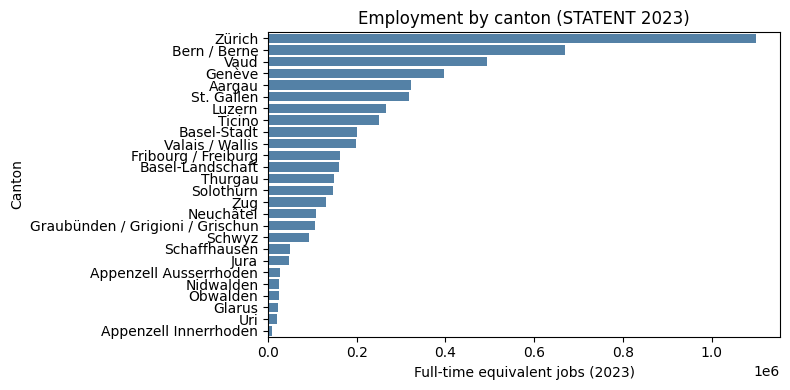

In [38]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=jobs_canton.sort_values("total_jobs_cantons", ascending=False),
    x="total_jobs_cantons",
    y="canton_name",
    color="steelblue"
)
plt.xlabel("Full-time equivalent jobs (2023)")
plt.ylabel("Canton")
plt.title("Employment by canton (STATENT 2023)")
plt.tight_layout()
plt.show()

### Total jobs per Canton

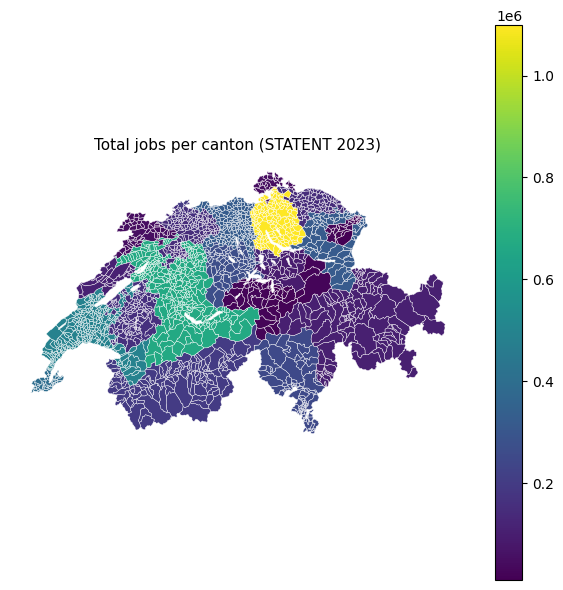

In [39]:
gdf_canton = cantons.merge(
    jobs_canton,
    left_on="KTNR",
    right_on="canton_id",
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_canton.plot(
    column="total_jobs_cantons",
    cmap="viridis",
    linewidth=0.3,
    edgecolor="white",
    legend=True,
    ax=ax
)
ax.set_axis_off()
ax.set_title("Total jobs per canton (STATENT 2023)", fontsize=11)
plt.tight_layout()
plt.show()

### Total jobs per municipality

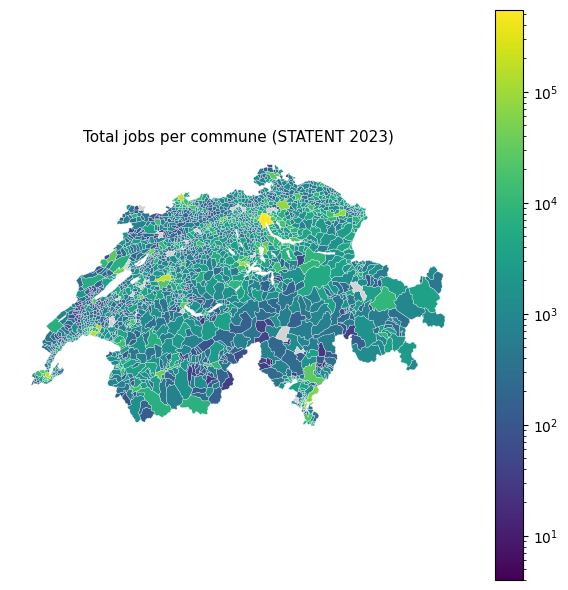

In [40]:
gdf_commune = cantons.merge(
    jobs_commune,
    left_on="GDENR",
    right_on="commune_id",
    how="left"
)

# Log scale requires strictly positive values
gdf_commune["total_jobs_commune_log"] = gdf_commune["total_jobs_commune"].where(
    gdf_commune["total_jobs_commune"] > 0
)

vmin = gdf_commune["total_jobs_commune_log"].min()
vmax = gdf_commune["total_jobs_commune_log"].max()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_commune.plot(
    column="total_jobs_commune_log",
    cmap="viridis",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data / zero"}
)
ax.set_axis_off()
ax.set_title("Total jobs per commune (STATENT 2023)", fontsize=11)
plt.tight_layout()
plt.show()

## Fifth Analysis: Public transport usage indicators Dataset

This dataset uses the following dataset: `passagierfrequenz.csv`

In [41]:
path_frequency_users = Path("data/passagierfrequenz.csv")

df = pd.read_csv(path_frequency_users, sep=";")

df.head()

,Code_Codice,UIC,Bahnhof_Gare_Stazione,Kt_Ct_Cantone,ISB_GI,Jahr_Annee_Anno,DTV_TJM_TGM,DWV_TMJO_TFM,DNWV_TMJNO_TMGNL,EVU_EF_ITF,Bemerkung,Bemerkungen,Note,Bemerkungen.1,lod,Geopos
0,ALT,8506319.0,Altstätten SG,SG,SBB,2024,2700.0,3100.0,1900.0,"SBB, SOB, Thurbo",NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.374234807062635, 9.556519883564428"
1,ALTD,8503211.0,Altendorf,SZ,SBB,2024,760.0,860.0,530.0,"SBB, SOB",NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.19396706593207, 8.822905848209773"
2,AND,8505165.0,Andermatt,UR,MGB,2022,2900.0,2800.0,3300.0,MGB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"46.636890087679205, 8.593280416936754"
3,BAA,8502206.0,Baar,ZG,SBB,2018,8900.0,10700.0,5000.0,SBB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.19536403756802, 8.523271537389258"
4,BAAL,8515993.0,Baar Lindenpark,ZG,SBB,2023,1200.0,1500.0,530.0,SBB,NaN,NaN,NaN,NaN,http://lod.opentransportdata.swiss/didok/didok85,"47.18313669446829, 8.517058460139534"


In [42]:
df = df.rename(columns={
    'Code_Codice': 'code',
    'UIC': 'uic',
    'Bahnhof_Gare_Stazione': 'station_name',
    'Kt_Ct_Cantone': 'canton',
    'ISB_GI': 'operator',
    'Jahr_Annee_Anno': 'year',
    'DTV_TJM_TGM': 'avg_users_per_day',
    'DWV_TMJO_TFM': 'avg_users_working_day',
    'DNWV_TMJNO_TMGNL': 'avg_users_non_working_day', 
    'EVU_EF_ITF': 'train_operators',
    'BemerkungBemerkungenNote': 'note',
    'Bemerkungen.1': 'note_2',
    'LOD': 'lod_url',
    'geopos': 'geopos'
})
print(df.columns.tolist())

df = df[df['year'] == 2024].copy()

['code', 'uic', 'station_name', 'canton', 'operator', 'year', 'avg_users_per_day', 'avg_users_working_day', 'avg_users_non_working_day', 'train_operators', 'Bemerkung', 'Bemerkungen', 'Note', 'note_2', 'lod', 'Geopos']


### Top 10 stations

In [43]:
# National top 10 stations
top10_national = (
    df
    .sort_values('avg_users_per_day', ascending=False)
    .head(10)
    [['station_name', 'canton', 'operator', 'avg_users_per_day']]
)

# Top 3 per canton 
top_per_canton = (
    df
    .sort_values(['canton', 'avg_users_per_day'], ascending=[True, False])
    .groupby('canton')
    .head(3)
    [['station_name', 'canton', 'operator', 'avg_users_per_day']]
)

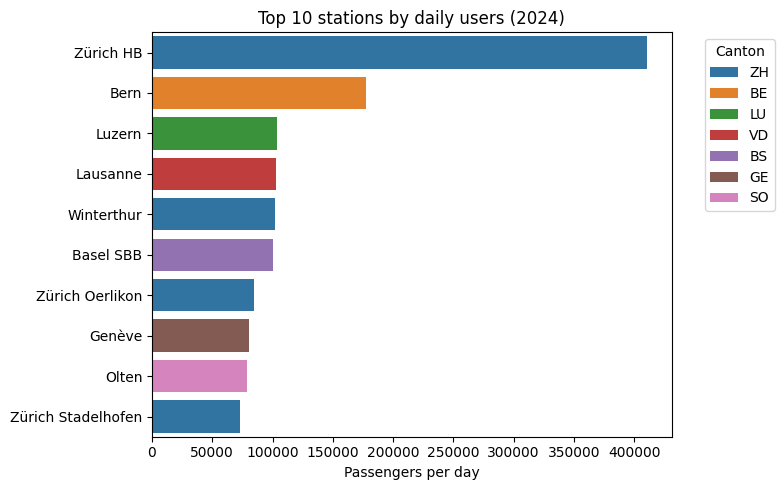

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top10_national,
    x='avg_users_per_day',
    y='station_name',
    hue='canton',
    dodge=False
)
plt.xlabel('Passengers per day')
plt.ylabel('')
plt.title('Top 10 stations by daily users (2024)')
plt.legend(title='Canton', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Top 3 stations per Canton

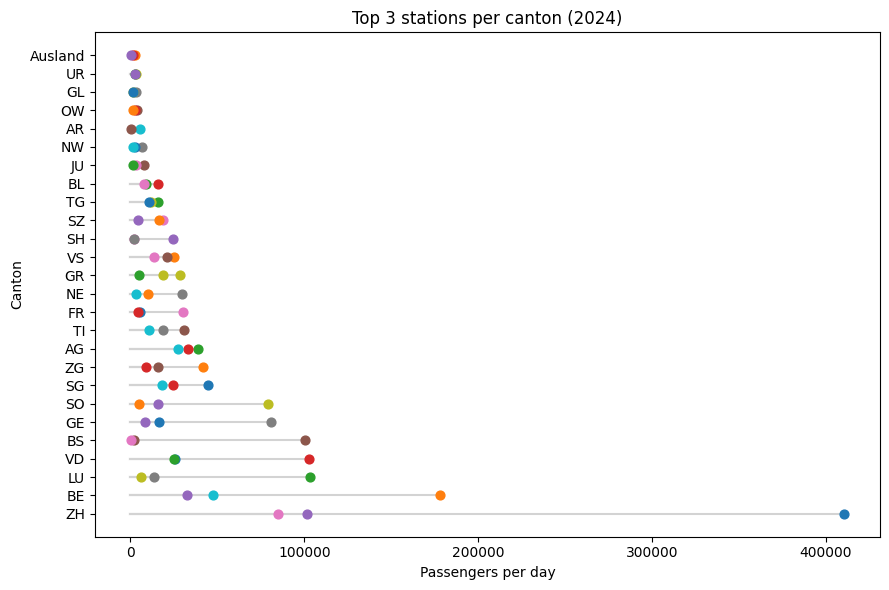

In [45]:
tmp = top_per_canton.sort_values('avg_users_per_day', ascending=False)

plt.figure(figsize=(9, 6))
for _, row in tmp.iterrows():
    plt.plot(
        [0, row['avg_users_per_day']],
        [row['canton'], row['canton']],
        color='lightgray',
        zorder=1
    )
    plt.scatter(
        row['avg_users_per_day'],
        row['canton'],
        s=40,
        label=row['station_name'],
        zorder=2
    )

plt.xlabel('Passengers per day')
plt.ylabel('Canton')
plt.title('Top 3 stations per canton (2024)')
plt.tight_layout()
plt.show()

### Average station use by Canton

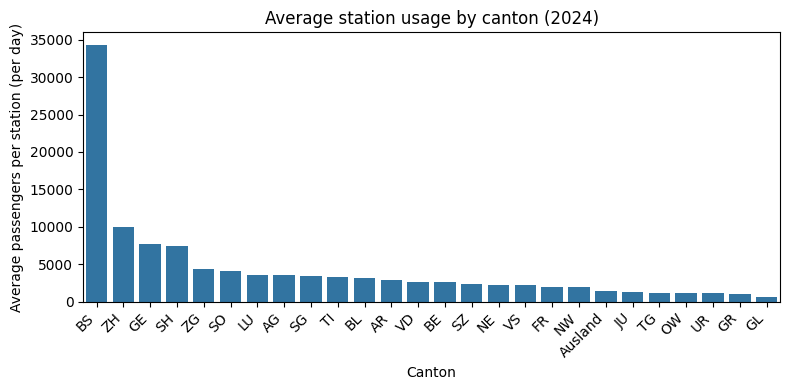

In [46]:
mean_by_canton = (
    df.groupby('canton')['avg_users_per_day']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=mean_by_canton,
    x='canton',
    y='avg_users_per_day'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average passengers per station (per day)')
plt.xlabel('Canton')
plt.title('Average station usage by canton (2024)')
plt.tight_layout()
plt.show()

### Station usage by operator in Switzerland

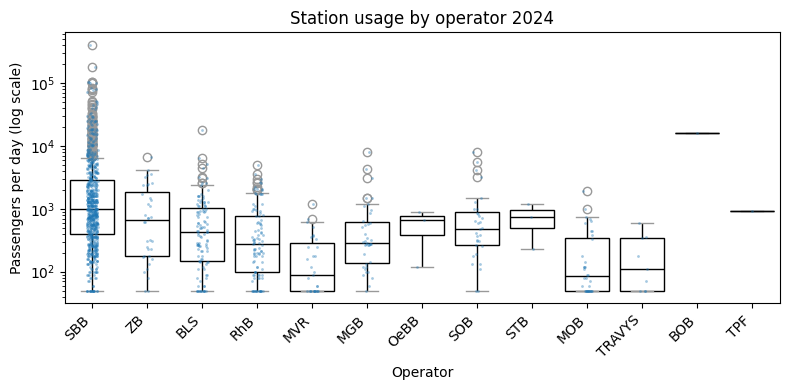

In [47]:
plt.figure(figsize=(8, 4))

# Boxplot per operator
sns.boxplot(
    data=df,
    x='operator',
    y='avg_users_per_day',
    color='white',
    showcaps=True,
    boxprops={'edgecolor': 'black'},
    medianprops={'color': 'black'},
    whiskerprops={'color': 'black'}
)

# Jittered points on top
sns.stripplot(
    data=df,
    x='operator',
    y='avg_users_per_day',
    color='tab:blue',
    alpha=0.4,
    size=2,
    jitter=True
)

plt.yscale('log')
plt.xlabel('Operator')
plt.ylabel('Passengers per day (log scale)')
plt.title('Station usage by operator 2024')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### SBB stations by average daily passengers

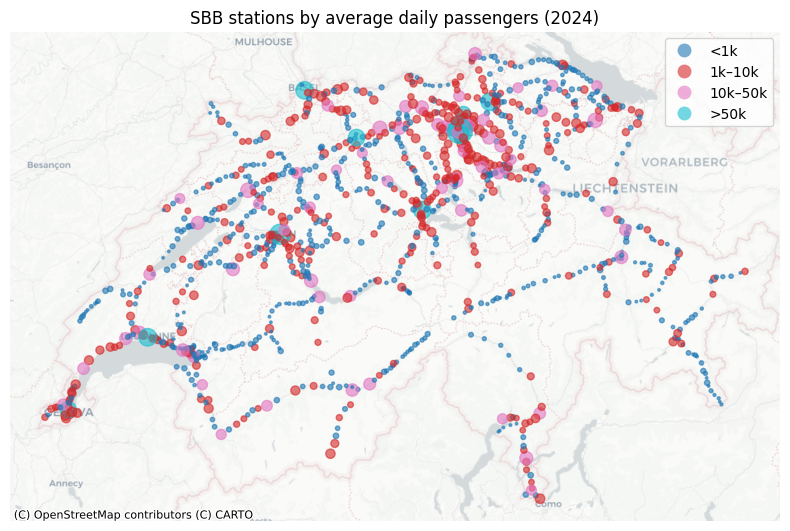

In [48]:
# Define size classes
bins = [0, 1000, 10000, 50000, np.inf]
labels = ['<1k', '1k–10k', '10k–50k', '>50k']
df['size_class'] = pd.cut(df['avg_users_per_day'], bins=bins, labels=labels, right=False)


# Split "lat, lon"
coords = df['Geopos'].str.split(',', expand=True).astype(float)
df['lat'] = coords[0]
df['lon'] = coords[1]

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
).to_crs("EPSG:3857") 

# Size for circles: function of usage (tune scaling factor)
gdf['circle_size'] = (gdf['avg_users_per_day'] ** 0.5) * 0.5

fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(
    ax=ax,
    column='size_class',
    markersize=gdf['circle_size'],
    legend=True,
    alpha=0.6
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron 
)

ax.set_axis_off()
plt.title(f"SBB stations by average daily passengers (2024)")
plt.tight_layout()
plt.show()

### Station usage: IC Hub vs other stations

In [49]:
#manually defined list of IC hubs 
ic_hubs = [
    'Zürich HB', 'Genève', 'Basel SBB', 'Bern', 'Luzern',
    'Lausanne', 'Winterthur', 'St. Gallen', 'Lugano', 'Biel/Bienne'
]

df['is_ic_hub'] = df['station_name'].isin(ic_hubs)

# Summary statistics
summary_ic = (
    df
    .groupby('is_ic_hub')['avg_users_per_day']
    .describe()
)

print(summary_ic)

            count           mean            std      min      25%       50%  \
is_ic_hub                                                                     
False      1146.0    2503.658813    6458.034516     49.0    242.5     685.0   
True         10.0  120010.000000  110381.746176  30600.0  55625.0  101150.0   

                75%       max  
is_ic_hub                      
False        1700.0   84600.0  
True       103325.0  410700.0  


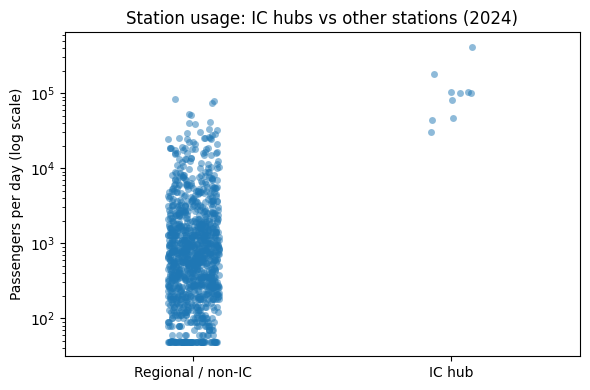

In [50]:
plt.figure(figsize=(6, 4))
sns.stripplot(
    data=df,
    x='is_ic_hub',
    y='avg_users_per_day',
    jitter=True,
    alpha=0.5
)

plt.yscale('log')  
plt.xticks([0, 1], ['Regional / non‑IC', 'IC hub'])
plt.ylabel('Passengers per day (log scale)')
plt.xlabel('')
plt.title(f"Station usage: IC hubs vs other stations ({2024})")

plt.tight_layout()
plt.show()
